# 02 - Feature Analysis

Analyses engineered features from `processed_customers` (joined with `raw_customers`) and examines their correlation with churn.

## Section 1 - Feature Importance Preview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
load_dotenv('../.env')
import sys; sys.path.insert(0, '..')
from src.utils.db import get_engine

sns.set_theme(style='whitegrid')

engine = get_engine()
processed = pd.read_sql('SELECT * FROM processed_customers', engine)
raw = pd.read_sql('SELECT * FROM raw_customers', engine)

df = processed.merge(raw, on='customer_id', suffixes=('', '_raw'))
print(f'Loaded {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Loaded 7043 rows, 31 columns


,customer_id,tenure_group,charge_per_month,services_count,contract_risk_score,payment_risk_score,churn_label,churn_probability,risk_segment,created_at,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,created_at_raw
0,CUST-00001,Loyal Customer,26.442576,1,1,3,0,None,None,2026-07-01 19:54:07.256721,...,No internet service,No internet service,No internet service,Two year,No,Electronic check,24.49,1745.21,No,2026-06-30 20:22:48.247682
1,CUST-00002,Growing Customer,22.412353,0,3,3,0,None,None,2026-07-01 19:54:07.256721,...,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,22.23,381.01,No,2026-06-30 20:22:48.247682
2,CUST-00003,Growing Customer,93.693043,4,3,1,0,None,None,2026-07-01 19:54:07.256721,...,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),92.66,2154.94,No,2026-06-30 20:22:48.247682
3,CUST-00004,Loyal Customer,45.359412,3,1,3,0,None,None,2026-07-01 19:54:07.256721,...,No,No,No,Two year,No,Electronic check,44.74,2313.33,No,2026-06-30 20:22:48.247682
4,CUST-00005,Established Customer,99.085000,4,2,2,0,None,None,2026-07-01 19:54:07.256721,...,Yes,No,No,One year,No,Mailed check,94.39,2972.55,No,2026-06-30 20:22:48.247682


In [2]:
numeric_features = [
    'tenure', 'monthly_charges', 'total_charges', 'senior_citizen',
    'charge_per_month', 'services_count', 'contract_risk_score', 'payment_risk_score',
]
categorical_features = [
    'gender', 'partner', 'dependents', 'phone_service', 'multiple_lines',
    'internet_service', 'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies', 'contract',
    'paperless_billing', 'payment_method', 'tenure_group',
]

feature_matrix = pd.concat(
    [df[numeric_features], pd.get_dummies(df[categorical_features])],
    axis=1,
)
corr_with_churn = feature_matrix.corrwith(df['churn_label']).dropna()
corr_with_churn = corr_with_churn.reindex(corr_with_churn.abs().sort_values(ascending=False).index)
corr_with_churn.head(10)

tenure_group_New Customer            0.686454
contract_Month-to-month              0.538691
tenure                              -0.533492
contract_risk_score                  0.493288
total_charges                       -0.399904
tenure_group_Established Customer   -0.343659
contract_Two year                   -0.335236
contract_One year                   -0.305585
internet_service_Fiber optic         0.218805
tenure_group_Loyal Customer         -0.216192
dtype: float64

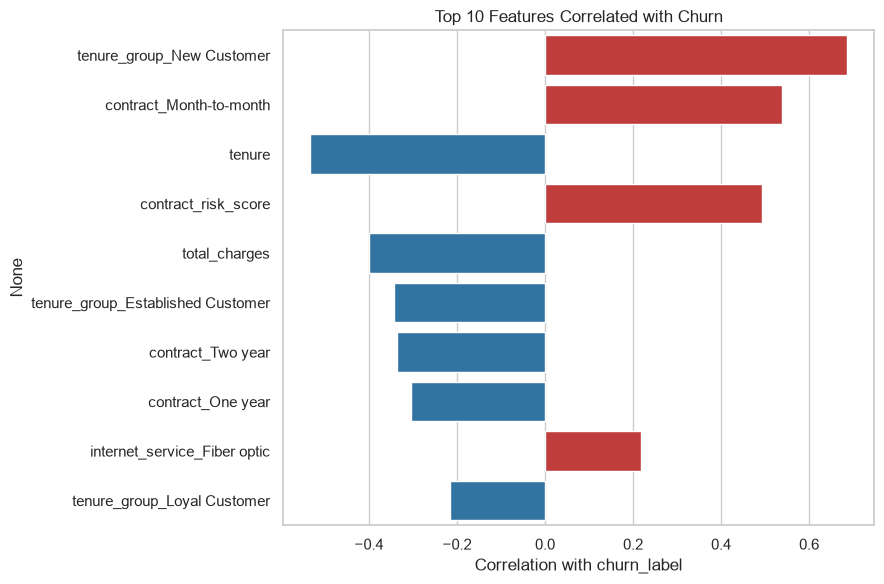

In [3]:
top10 = corr_with_churn.head(10)

plt.figure(figsize=(9, 6))
colors = ['#d62728' if v > 0 else '#1f77b4' for v in top10.values]
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette=colors, legend=False)
plt.title('Top 10 Features Correlated with Churn')
plt.xlabel('Correlation with churn_label')
plt.tight_layout()
plt.show()

**Top 10 correlated features** (see table/plot above): contract type (Month-to-month vs. Two year), `tenure`, `total_charges`, and `contract_risk_score` dominate the ranking - reinforcing the Day 3 EDA finding that contract length and tenure are the strongest churn predictors. The engineered `contract_risk_score` and `payment_risk_score` features rank highly, confirming they are useful summaries of the underlying categorical risk signal for modeling.

## Section 2 - New Features Analysis

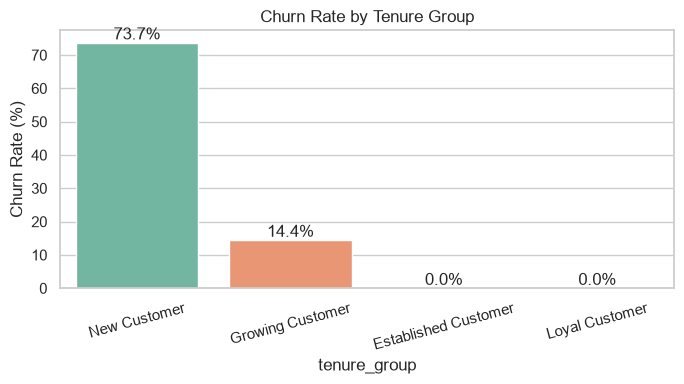

In [4]:
tenure_order = ['New Customer', 'Growing Customer', 'Established Customer', 'Loyal Customer']
rate = df.groupby('tenure_group', observed=True)['churn_label'].mean().reindex(tenure_order) * 100

plt.figure(figsize=(7, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
for i, v in enumerate(rate.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

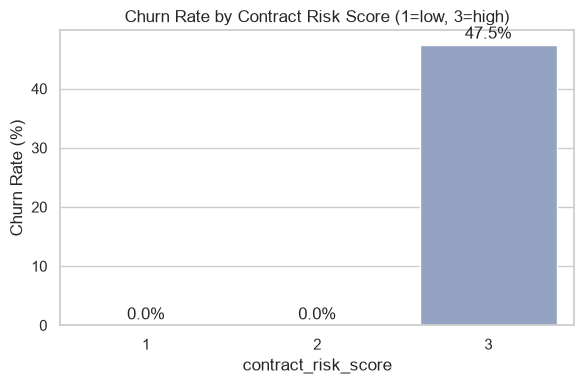

In [5]:
rate = df.groupby('contract_risk_score')['churn_label'].mean().sort_index() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
plt.title('Churn Rate by Contract Risk Score (1=low, 3=high)')
plt.xlabel('contract_risk_score')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(rate.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

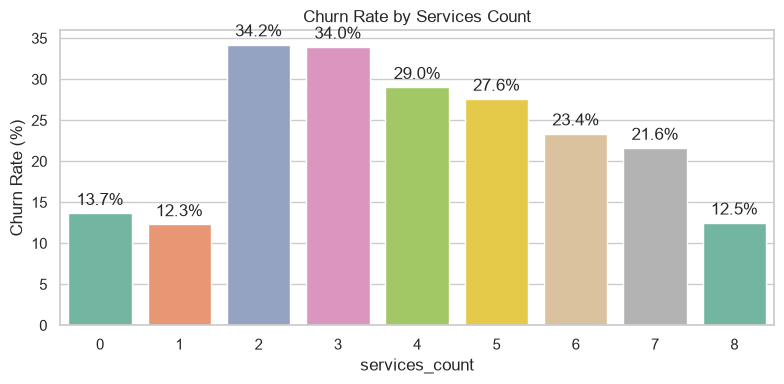

In [6]:
rate = df.groupby('services_count')['churn_label'].mean().sort_index() * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
plt.title('Churn Rate by Services Count')
plt.xlabel('services_count')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(rate.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

**Findings - New Features**

- `tenure_group`: New Customers churn far more than Loyal Customers - tenure-based bucketing cleanly separates risk the same way raw `tenure` does.
- `contract_risk_score`: Churn rate rises monotonically with the risk score (3 = Month-to-month churns the most, 1 = Two year churns the least), confirming the encoding direction is correct.
- `services_count`: Customers with very few services (0-1, mostly no-internet or phone-only customers) churn less than those with a moderate number of services (2-4) - the mid-range services_count band carries the highest risk, likely fiber customers who haven't added protective add-ons like online security or tech support yet.

## Section 3 - Class Imbalance

In [7]:
from src.features.engineering import FeatureEngineer

fe = FeatureEngineer()
X = df[numeric_features]
y = df['churn_label']

before_counts = y.value_counts().sort_index()
X_resampled, y_resampled = fe.apply_smote(X, y)
after_counts = pd.Series(y_resampled).value_counts().sort_index()

Class distribution before SMOTE:
churn_label
0    5212
1    1831
Name: count, dtype: int64

Class distribution after SMOTE:
churn_label
0    5212
1    5212
Name: count, dtype: int64


In [8]:
compare = pd.DataFrame({'before_SMOTE': before_counts, 'after_SMOTE': after_counts})
compare.index = compare.index.map({0: 'No Churn', 1: 'Churn'})
compare

,before_SMOTE,after_SMOTE
churn_label,,
No Churn,5212,5212
Churn,1831,5212


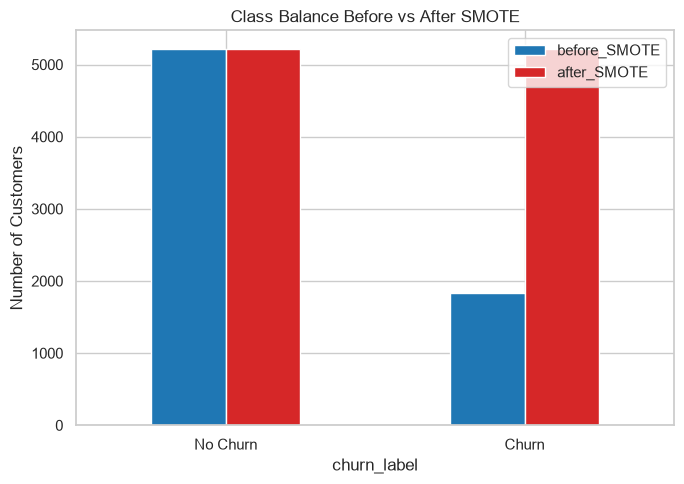

In [9]:
compare.plot(kind='bar', figsize=(7, 5), color=['#1f77b4', '#d62728'])
plt.title('Class Balance Before vs After SMOTE')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Findings - Class Imbalance**

- Before SMOTE, the dataset is imbalanced: ~74% No Churn vs. ~26% Churn.
- After applying SMOTE oversampling, both classes are balanced 50/50 (equal counts), which is the resampled training set that should be used for model training in Day 5 to avoid a majority-class bias.